<h2><center>HANDLING OUTLIERS & MISSING VALUES IN A DATASET</h2>



<h4>To preprocess the dataset by removing duplicates, detecting outliers, and handling missing values using Pandas and Scikit-learn
SimpleImputer.</h4>


<h2> 1: Import the basic libraries</h2>


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


<h2> 2: Load & Analyze the Dataset</h2>

In [5]:
thrilokya_128 = pd.read_csv('product_sales_dataset.csv')

In [6]:
## Dataset Info
thrilokya_128.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order ID         1005 non-null   int64  
 1   Product          1005 non-null   object 
 2   Category         1005 non-null   object 
 3   Quantity         979 non-null    float64
 4   Price            975 non-null    float64
 5   Customer Rating  980 non-null    float64
 6   City             985 non-null    object 
dtypes: float64(3), int64(1), object(3)
memory usage: 55.1+ KB


In [7]:
thrilokya_128.head()

,Order ID,Product,Category,Quantity,Price,Customer Rating,City
0,5001,Smartwatch,Accessories,3.0,23784.55,1.39,Delhi
1,5002,Smartphone,Electronics,8.0,18833.40,2.22,Jaipur
2,5003,Monitor,Computers,7.0,6285.43,2.96,Delhi
3,5004,Headphones,Electronics,3.0,30242.08,1.46,Jaipur
4,5005,Headphones,Accessories,5.0,20860.29,1.60,Jaipur


In [8]:
thrilokya_128.shape

(1005, 7)

In [9]:
thrilokya_128.describe()

,Order ID,Quantity,Price,Customer Rating
count,1005.000000,979.000000,975.000000,980.000000
mean,5500.004975,5.277835,25703.615651,2.992582
std,288.573054,4.579052,12381.063944,1.186639
min,5001.000000,1.000000,-1138.130000,-1.000000
25%,5251.000000,3.000000,18864.670000,1.960000
50%,5500.000000,5.000000,25408.150000,2.970000
75%,5749.000000,7.000000,31361.870000,4.060000
max,6000.000000,100.000000,200000.000000,9.000000


<h2>3: Find & Remove Duplicates</h2>

In [10]:
#Check number of duplicate rows
thrilokya_128.duplicated().sum()

np.int64(5)

In [11]:
#Display duplicate rows
thrilokya_128[thrilokya_128.duplicated()]

,Order ID,Product,Category,Quantity,Price,Customer Rating,City
1000,5101,Smartwatch,Electronics,NaN,27422.14,2.23,Hyderabad
1001,5251,Laptop,Computers,7.0,31565.37,4.02,Jaipur
1002,5401,Monitor,Accessories,1.0,16548.23,1.85,Bengaluru
1003,5551,Monitor,Computers,3.0,30204.14,1.16,Bengaluru
1004,5701,Smartwatch,Computers,4.0,24635.52,4.16,Hyderabad


In [12]:
#Remove duplicate rows
thrilokya_128 = thrilokya_128.drop_duplicates()

In [13]:
#Check the shape after removing duplicates
thrilokya_128.shape

(1000, 7)

In [14]:
#Verify duplicates are removed
thrilokya_128.duplicated().sum()

np.int64(0)

<h2>4: Identify & Remove Outliers</h2>

In [15]:
#Create a list of outlier columns
columns = ['Quantity', 'Price', 'Customer Rating']

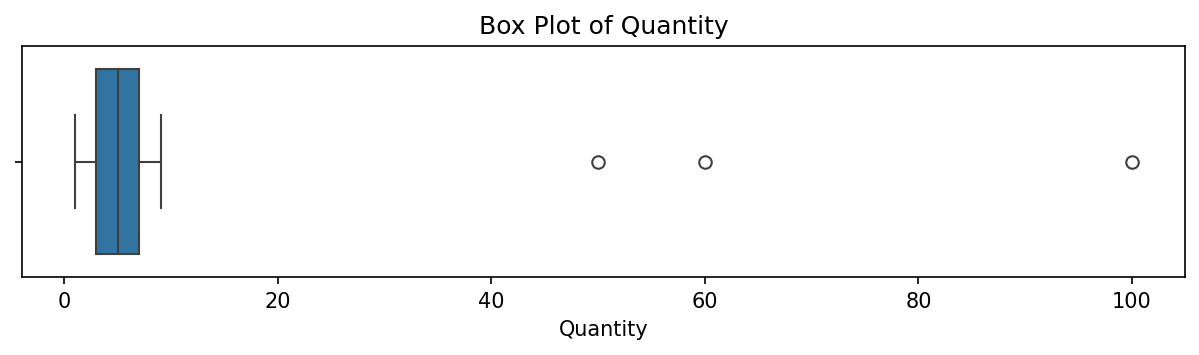

In [16]:
#Box plot for Quantity
plt.figure(figsize=(10, 2), dpi=150)

sns.boxplot(data=thrilokya_128['Quantity'], orient='h')

plt.title('Box Plot of Quantity')
plt.show()

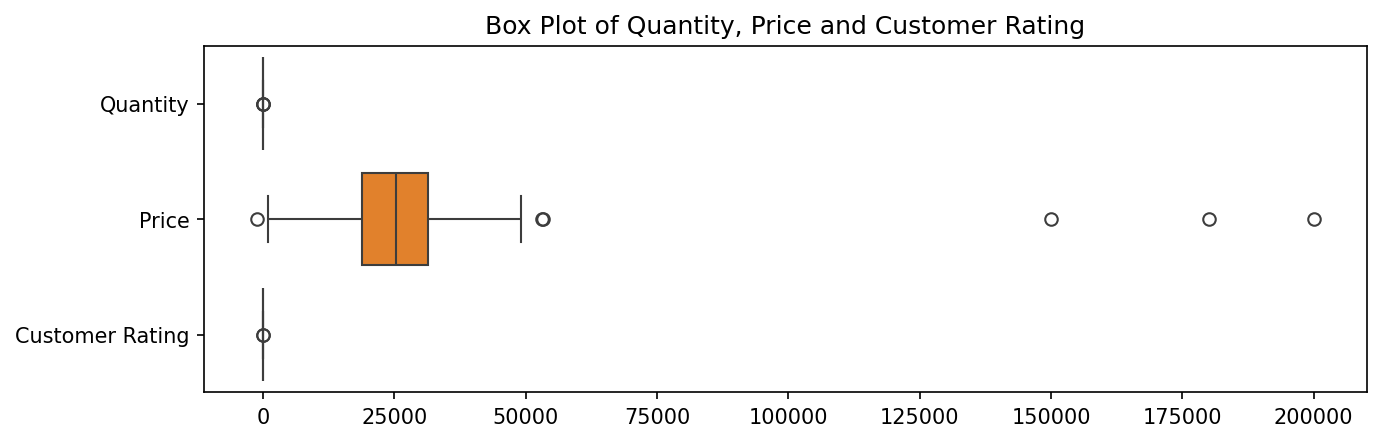

In [17]:
#Box plot for all numerical columns
plt.figure(figsize=(10, 3), dpi=150)

sns.boxplot(data=thrilokya_128[columns], orient='h')

plt.title('Box Plot of Quantity, Price and Customer Rating')
plt.show()

In [18]:
#Remove the Outliers with IQR Ranges
# Calculate the IQR Ranges (Q1 & Q3)
Q1 = thrilokya_128[columns].quantile(0.25)
Q3 = thrilokya_128[columns].quantile(0.75)

In [19]:
#display them 
Q1, Q3

(Quantity               3.000
 Price              18852.560
 Customer Rating        1.965
 Name: 0.25, dtype: float64,
 Quantity               7.00
 Price              31372.00
 Customer Rating        4.06
 Name: 0.75, dtype: float64)

In [20]:
# IQR
IQR = Q3 - Q1


In [21]:
# Find the Outliers with IQR Ranges
outliers = (thrilokya_128[columns] < (Q1 - 1.5 * IQR)) | (thrilokya_128[columns] > (Q3 + 1.5 * IQR))


In [22]:
# Total Outliers
outliers.sum()


Quantity           3
Price              6
Customer Rating    2
dtype: int64

In [23]:
# Shape of the df before outliers removal
thrilokya_128.shape

(1000, 7)

In [24]:
# Removing the Outliers (Keeping only non outliers data)
thrilokya_128 = thrilokya_128[~(outliers).any(axis=1)]


In [25]:
# Shape of the df after outliers removal
thrilokya_128.shape


(989, 7)

In [26]:
thrilokya_128.head()


,Order ID,Product,Category,Quantity,Price,Customer Rating,City
0,5001,Smartwatch,Accessories,3.0,23784.55,1.39,Delhi
1,5002,Smartphone,Electronics,8.0,18833.40,2.22,Jaipur
2,5003,Monitor,Computers,7.0,6285.43,2.96,Delhi
3,5004,Headphones,Electronics,3.0,30242.08,1.46,Jaipur
4,5005,Headphones,Accessories,5.0,20860.29,1.60,Jaipur


<h2>5: Fill the Missing Values</h2>

In [27]:
# Find out any missing values
thrilokya_128.isnull().sum()


Order ID            0
Product             0
Category            0
Quantity           25
Price              29
Customer Rating    25
City               20
dtype: int64

In [28]:
# Filling Quantity with mean value using numpy
thrilokya_128['Quantity'] = thrilokya_128['Quantity'].fillna(np.mean(thrilokya_128['Quantity'])
)

In [29]:
thrilokya_128['Quantity'].isnull().sum()

np.int64(0)

In [30]:
# Import the Simple Imputer
from sklearn.impute import SimpleImputer


In [31]:
# Create the Instance for Imputer
numerical_imputer = SimpleImputer(strategy='median')

In [32]:
# Filling Price & Customer Rating with Median value

thrilokya_128[['Price', 'Customer Rating']] = numerical_imputer.fit_transform(
    thrilokya_128[['Price', 'Customer Rating']]
)


In [33]:
thrilokya_128[['Price', 'Customer Rating']].isnull().sum()

Price              0
Customer Rating    0
dtype: int64

In [34]:
#Fill City with Mode using SimpleImputer
thrilokya_128['City'].value_counts()

City
Hyderabad    129
Kolkata      129
Jaipur       124
Bengaluru    122
Chennai      119
Delhi        118
Mumbai       116
Pune         112
Name: count, dtype: int64

In [35]:
# Filling City (Categorical) with Mode value using SimpleImputer

thrilokya_128['City'].value_counts()

City
Hyderabad    129
Kolkata      129
Jaipur       124
Bengaluru    122
Chennai      119
Delhi        118
Mumbai       116
Pune         112
Name: count, dtype: int64

In [36]:
# Create the Instance for Imputer

categorical_imputer = SimpleImputer(strategy='most_frequent')

In [37]:
# Impute the Values

thrilokya_128[['City']] = categorical_imputer.fit_transform(thrilokya_128[['City']])

In [38]:
# Check for the Imputed City Values

thrilokya_128['City'].value_counts()

City
Hyderabad    149
Kolkata      129
Jaipur       124
Bengaluru    122
Chennai      119
Delhi        118
Mumbai       116
Pune         112
Name: count, dtype: int64

<h2>Final Step: Check Cleaned Dataset</h2>

In [39]:
# Check for remaining missing values

thrilokya_128.isnull().sum()

Order ID           0
Product            0
Category           0
Quantity           0
Price              0
Customer Rating    0
City               0
dtype: int64

# Cleaned Dataset Info

thrilokya_128.info()

In [40]:
# Display the first 5 rows of cleaned dataset

thrilokya_128.head()

,Order ID,Product,Category,Quantity,Price,Customer Rating,City
0,5001,Smartwatch,Accessories,3.0,23784.55,1.39,Delhi
1,5002,Smartphone,Electronics,8.0,18833.40,2.22,Jaipur
2,5003,Monitor,Computers,7.0,6285.43,2.96,Delhi
3,5004,Headphones,Electronics,3.0,30242.08,1.46,Jaipur
4,5005,Headphones,Accessories,5.0,20860.29,1.60,Jaipur


<h1>RESULT:</h1>
<h4>By using Pandas and Scikit-learn, duplicates were removed, outliers were detected and dropped, and missing values were filled using
mean, median, and most frequent methods. The dataset is now clean and ready for further analysis.</h4>

<h2>Conclusion</h2>
<h4>Thus, the dataset was successfully preprocessed by identifying and removing duplicate 
records, detecting outliers, and handling missing values. Pandas and Scikit-learn 
SimpleImputer were used for the preprocessing tasks. The experiment demonstrated the 
importance of data cleaning in preparing a dataset for further analysis.</h4>